# S

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/employee-attrition-and-factors/HR_Analytics.csv.csv


In [21]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_name="/kaggle/input/employee-attrition-and-factors/HR_Analytics.csv.csv"
df = pd.read_csv(file_name)
df.head()



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
import numpy as np

# Separate columns into categorical and numerical
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Check value counts for target column 'Attrition' to check for balance
attrition_counts = df['Attrition'].value_counts()
attrition_percentage = df['Attrition'].value_counts(normalize=True) * 100

{
    "Categorical Columns": categorical_cols,
    "Numerical Columns": numerical_cols,
    "Attrition Counts": attrition_counts.to_dict(),
    "Attrition Percentages": attrition_percentage.round(2).to_dict()
}


{'Categorical Columns': ['Attrition',
  'BusinessTravel',
  'Department',
  'EducationField',
  'Gender',
  'JobRole',
  'MaritalStatus',
  'Over18',
  'OverTime'],
 'Numerical Columns': ['Age',
  'DailyRate',
  'DistanceFromHome',
  'Education',
  'EmployeeCount',
  'EmployeeNumber',
  'EnvironmentSatisfaction',
  'HourlyRate',
  'JobInvolvement',
  'JobLevel',
  'JobSatisfaction',
  'MonthlyIncome',
  'MonthlyRate',
  'NumCompaniesWorked',
  'PercentSalaryHike',
  'PerformanceRating',
  'RelationshipSatisfaction',
  'StandardHours',
  'StockOptionLevel',
  'TotalWorkingYears',
  'TrainingTimesLastYear',
  'WorkLifeBalance',
  'YearsAtCompany',
  'YearsInCurrentRole',
  'YearsSinceLastPromotion',
  'YearsWithCurrManager'],
 'Attrition Counts': {'No': 1233, 'Yes': 237},
 'Attrition Percentages': {'No': 83.88, 'Yes': 16.12}}

In [ ]:
# Frequency and percentage for categorical columns
categorical_summary = {}
for col in categorical_cols:
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    categorical_summary[col] = pd.DataFrame({'Count': counts, 'Percentage': percentages.round(2)})

# Summary statistics Z

In [ ]:
numerical_summary = df[numerical_cols].describe().T
numerical_summary["variance"] = df[numerical_cols].var()
numerical_summary = numerical_summary[["mean", "50%", "variance", "std"]]
numerical_summary.rename(columns={"50%": "median"}, inplace=True)

categorical_summary, numerical_summary.round(2)

({'Attrition':            Count  Percentage
  Attrition                   
  No          1233       83.88
  Yes          237       16.12,
  'BusinessTravel':                    Count  Percentage
  BusinessTravel                      
  Travel_Rarely       1043       70.95
  Travel_Frequently    277       18.84
  Non-Travel           150       10.20,
  'Department':                         Count  Percentage
  Department                               
  Research & Development    961       65.37
  Sales                     446       30.34
  Human Resources            63        4.29,
  'EducationField':                   Count  Percentage
  EducationField                     
  Life Sciences       606       41.22
  Medical             464       31.56
  Marketing           159       10.82
  Technical Degree    132        8.98
  Other                82        5.58
  Human Resources      27        1.84,
  'Gender':         Count  Percentage
  Gender                   
  Male      882        6

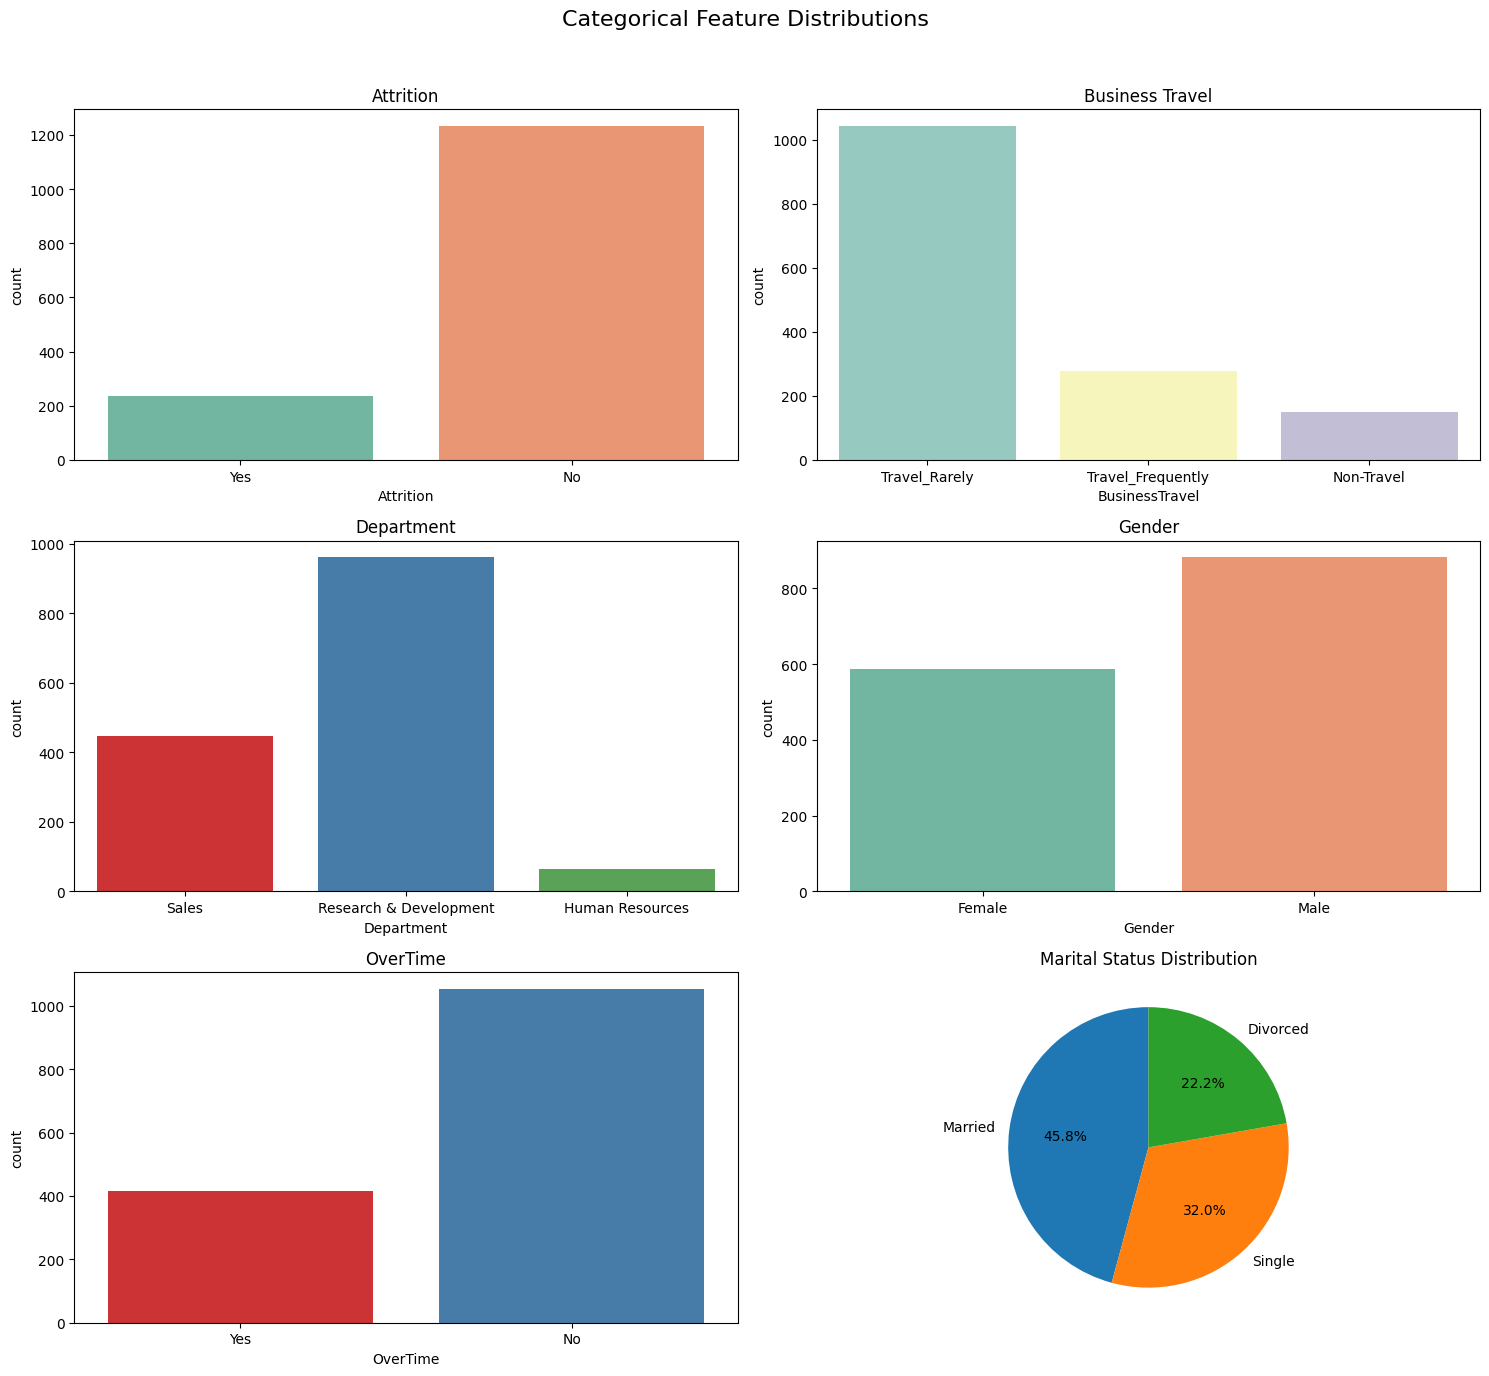

In [9]:


# Plotting key categorical columns
fig, axes = plt.subplots(3, 2, figsize=(15, 14))
fig.suptitle('Categorical Feature Distributions', fontsize=16)

# Attrition
sns.countplot(data=df, x='Attrition', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Attrition')

# BusinessTravel
sns.countplot(data=df, x='BusinessTravel', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title('Business Travel')

# Department
sns.countplot(data=df, x='Department', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Department')

# Gender
sns.countplot(data=df, x='Gender', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Gender')

# OverTime
sns.countplot(data=df, x='OverTime', ax=axes[2, 0], palette='Set1')
axes[2, 0].set_title('OverTime')

# MaritalStatus pie chart
df['MaritalStatus'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=axes[2, 1])
axes[2, 1].set_ylabel('')
axes[2, 1].set_title('Marital Status Distribution')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


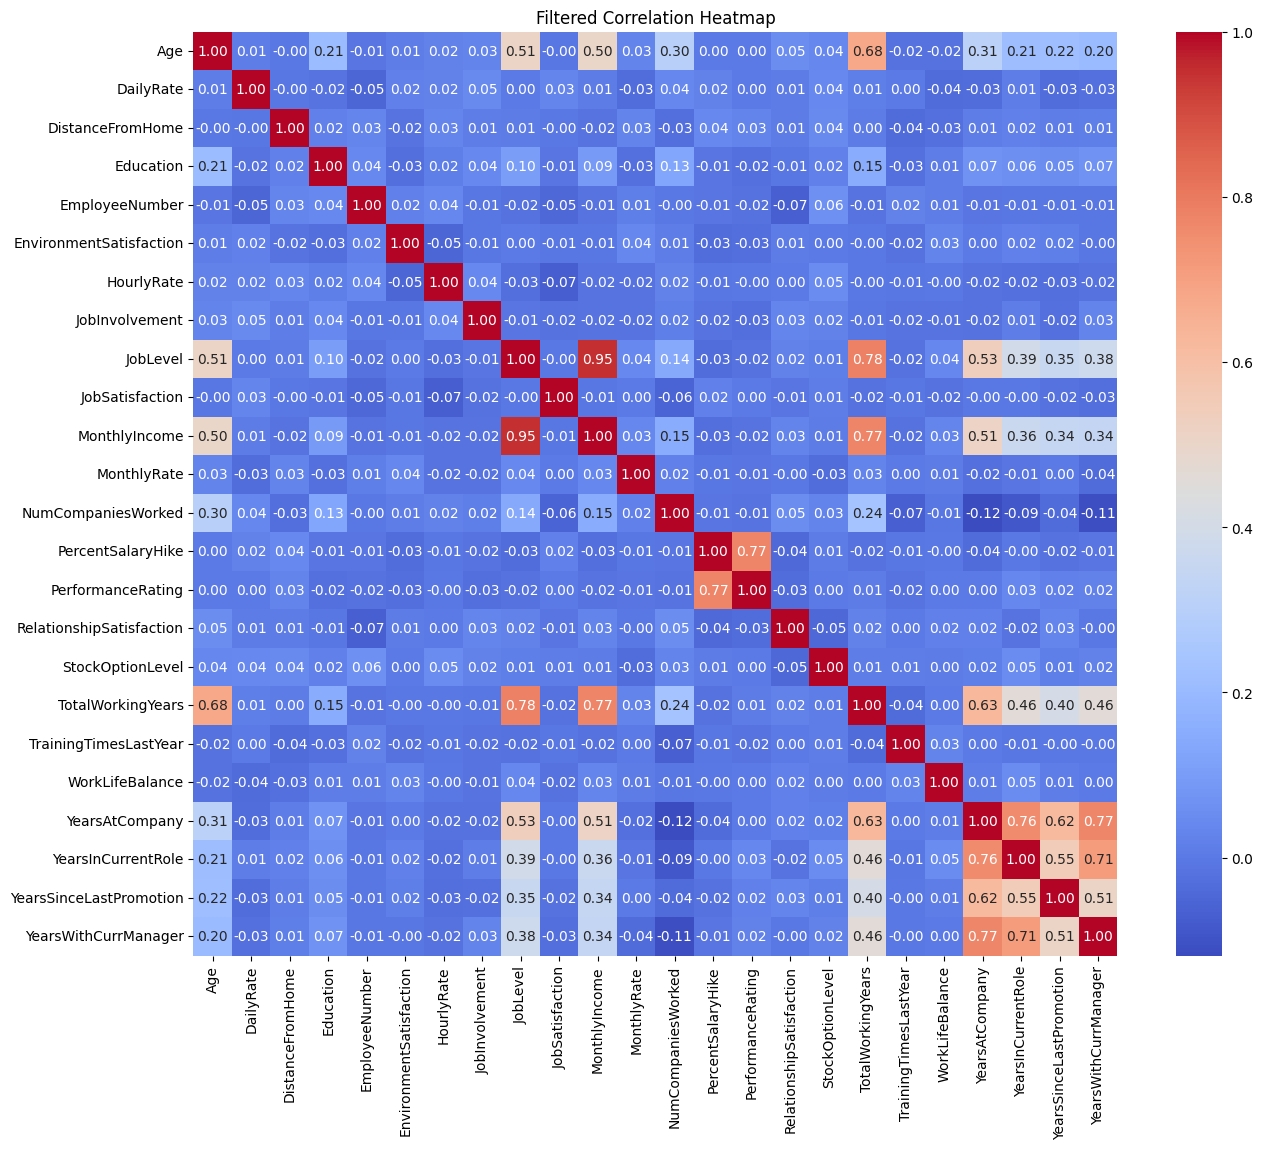

In [19]:
# Filter numerical columns to remove constant and NaN-only columns
filtered_df = df[numerical_cols].replace([np.inf, -np.inf], np.nan).dropna(axis=1, how='any')
filtered_df = filtered_df.loc[:, filtered_df.nunique() > 1]

# Plot heatmap
plt.figure(figsize=(15, 12))
corr = filtered_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Filtered Correlation Heatmap")
plt.show()


In [18]:
df_encoded = pd.get_dummies(df, drop_first=True)
print("\nEncoded DataFrame shape:", df_encoded.shape)


Encoded DataFrame shape: (1470, 48)


In [14]:
# Check for missing values in each column
print(df.isnull().sum())

# Display rows with missing data
print(df[df.isnull().any(axis=1)])


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince